## Wearable Tech: Week 3 Assignment

### Step 1

In [1]:
#imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates

from datetime import datetime
import plotly.graph_objects as go

df = pd.read_csv("../Data/WBBtotal.csv", index_col =["Timestamp"], parse_dates=["Timestamp"])

### Step 2

In [2]:
columns_to_keep = ['Seconds','Heart Rate', 'Player Load', 'AthleteID']

df_wbb = df[columns_to_keep]
df_wbb

,Seconds,Heart Rate,Player Load,AthleteID
Timestamp,,,,
2019-01-08 17:39:42,0.0,83,0.0,Athlete 1
2019-01-08 17:39:42,0.1,83,0.0,Athlete 1
2019-01-08 17:39:42,0.2,83,0.0,Athlete 1
2019-01-08 17:39:42,0.3,83,0.0,Athlete 1
2019-01-08 17:39:42,0.4,83,0.0,Athlete 1
...,...,...,...,...
2019-03-08 16:47:03,11484.4,101,1001.5,Athlete 5
2019-03-08 16:47:03,11484.5,101,1001.5,Athlete 5
2019-03-08 16:47:03,11484.6,101,1001.5,Athlete 5


In [35]:
df_wbb[df_wbb['Heart Rate']==0]

,Seconds,Heart Rate,Player Load,AthleteID
Timestamp,,,,
2019-01-08 18:14:25,2083.5,0,129.4,Athlete 1
2019-01-08 18:14:25,2083.6,0,129.4,Athlete 1
2019-01-08 18:14:25,2083.7,0,129.4,Athlete 1
2019-01-08 18:14:25,2083.8,0,129.4,Athlete 1
2019-01-08 18:14:25,2083.9,0,129.4,Athlete 1
...,...,...,...,...
2019-03-08 16:42:04,11185.6,0,983.5,Athlete 5
2019-03-08 16:42:04,11185.7,0,983.5,Athlete 5
2019-03-08 16:42:05,11185.8,0,983.5,Athlete 5


### Step 3

In [36]:
Game_3_8_df = df_wbb.loc['2019-03-09']
Game_3_8_df

,Seconds,Heart Rate,Player Load,AthleteID
Timestamp,,,,
2019-03-09 15:57:49,0.0,0,0.0,Athlete 10
2019-03-09 15:57:49,0.1,0,0.0,Athlete 10
2019-03-09 15:57:49,0.2,0,0.0,Athlete 10
2019-03-09 15:57:49,0.3,0,0.0,Athlete 10
2019-03-09 15:57:49,0.4,0,0.0,Athlete 10
...,...,...,...,...
2019-03-09 19:08:14,11348.4,108,470.6,Athlete 8
2019-03-09 19:08:14,11348.5,106,470.6,Athlete 8
2019-03-09 19:08:14,11348.6,106,470.6,Athlete 8


### Step 4

In [37]:
(Game_3_8_df == 0).sum(axis=0)  # we are just capturing the number of cells with a zero in them for each column in the entire team dataframe

Seconds           13
Heart Rate     69452
Player Load      391
AthleteID          0
dtype: int64

### Step 5

In [38]:
%%capture
Game_3_8_df.loc[Game_3_8_df['Heart Rate'] ==0, 'Heart Rate'] = np.nan

In [39]:
DataCount = Game_3_8_df.groupby('AthleteID')['Heart Rate','Player Load'].count()

print("Count of heart rate and playerload by player ID")
print(DataCount.sort_values(by='Heart Rate', ascending = False))

Count of heart rate and playerload by player ID
            Heart Rate  Player Load
AthleteID                          
Athlete 7       111604       113355
Athlete 4       110829       113749
Athlete 1       110378       113379
Athlete 8       109899       113489
Athlete 2       109071       113829
Athlete 12      109057       113689
Athlete 6       108862       113579
Athlete 5       108154       113629
Athlete 9       108116       113819
Athlete 3       106787       113519
Athlete 13      105498       113346
Athlete 11      105176       113469
Athlete 10      104229       114261


In [40]:
DataCount['Missing HR values']= (DataCount['Player Load']-DataCount['Heart Rate'])
DataCount['% HR missing'] = DataCount['Missing HR values']/DataCount['Player Load']*100

print(DataCount.sort_values(by='% HR missing', ascending = False))

            Heart Rate  Player Load  Missing HR values  % HR missing
AthleteID                                                           
Athlete 10      104229       114261              10032      8.779899
Athlete 11      105176       113469               8293      7.308604
Athlete 13      105498       113346               7848      6.923932
Athlete 3       106787       113519               6732      5.930285
Athlete 9       108116       113819               5703      5.010587
Athlete 5       108154       113629               5475      4.818312
Athlete 2       109071       113829               4758      4.179954
Athlete 6       108862       113579               4717      4.153056
Athlete 12      109057       113689               4632      4.074273
Athlete 8       109899       113489               3590      3.163302
Athlete 1       110378       113379               3001      2.646875
Athlete 4       110829       113749               2920      2.567056
Athlete 7       111604       11335

### Step 6


In [41]:
Ath10_Game_3_8_df = Game_3_8_df.loc[Game_3_8_df['AthleteID'] == 'Athlete 10'] 
Ath6_Game_3_8_df = Game_3_8_df.loc[Game_3_8_df['AthleteID'] == 'Athlete 6'] 

AthleteID
Athlete 10    AxesSubplot(0.125,0.125;0.775x0.755)
Athlete 6     AxesSubplot(0.125,0.125;0.775x0.755)
dtype: object

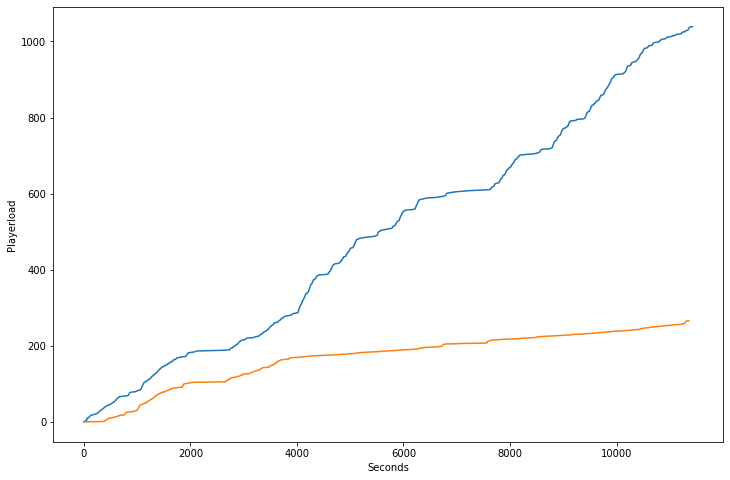

In [42]:
(Game_3_8_df.query("AthleteID == 'Athlete 10' or AthleteID == 'Athlete 6'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Player Load", ax=plt.gca(), ylabel="Playerload", figsize=(12,8), legend=False))

AthleteID
Athlete 10    AxesSubplot(0.125,0.125;0.775x0.755)
Athlete 6     AxesSubplot(0.125,0.125;0.775x0.755)
dtype: object

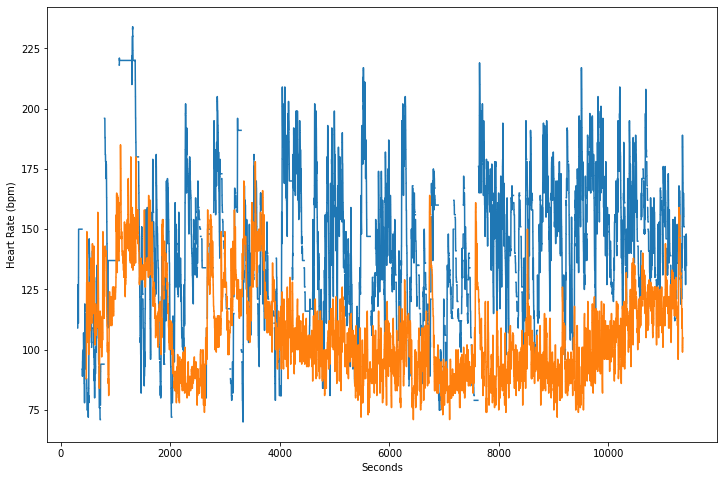

In [43]:
(Game_3_8_df.query("AthleteID == 'Athlete 10' or AthleteID == 'Athlete 6'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Heart Rate", ax=plt.gca(), ylabel="Heart Rate (bpm)", figsize=(12,8), legend=False))

### Step 7

<AxesSubplot:xlabel='Seconds'>

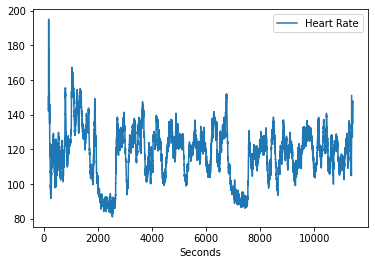

In [44]:
Team_Mean_HR2 = Game_3_8_df.groupby(['Seconds'])[['Heart Rate']].mean()
Team_Mean_HR2.plot(y='Heart Rate')

### Step 8


In [45]:
Rank_Mean_HR = Game_3_8_df.groupby(['AthleteID'])[['Heart Rate']].mean()

print("Average heart rate by player ID")
print(Rank_Mean_HR.sort_values(by='Heart Rate', ascending = False))

Average heart rate by player ID
            Heart Rate
AthleteID             
Athlete 10  143.739545
Athlete 9   143.422047
Athlete 1   143.249696
Athlete 7   140.687171
Athlete 5   132.837472
Athlete 2   120.254834
Athlete 8   113.139310
Athlete 13  109.495981
Athlete 11  108.726088
Athlete 6   107.771711
Athlete 3    93.868420
Athlete 12   90.120524
Athlete 4    84.351072


In [46]:
t= 12000/60  # 12000 seconds divided by 60 to provide minutes (200 minutes in this double-overtime game with warm-up time included)

HRmax=200
HRrest=60

FHRR = (Rank_Mean_HR['Heart Rate']-HRrest)/ (HRmax-HRrest)

In [47]:
kval = (np.exp(1.67 * FHRR))
print(FHRR)

TRIMP = t * FHRR * kval

AthleteID
Athlete 1     0.594641
Athlete 10    0.598140
Athlete 11    0.348043
Athlete 12    0.215147
Athlete 13    0.353543
Athlete 2     0.430392
Athlete 3     0.241917
Athlete 4     0.173936
Athlete 5     0.520268
Athlete 6     0.341227
Athlete 7     0.576337
Athlete 8     0.379566
Athlete 9     0.595872
Name: Heart Rate, dtype: float64


In [48]:
InternalLoads=pd.concat([TRIMP, Rank_Mean_HR], axis=1)
InternalLoads.columns=['TRIMP Values','MEAN HR Values']
print(InternalLoads)

            TRIMP Values  MEAN HR Values
AthleteID                               
Athlete 1     321.041173      143.249696
Athlete 10    324.822671      143.739545
Athlete 11    124.477146      108.726088
Athlete 12     61.631714       90.120524
Athlete 13    127.610514      109.495981
Athlete 2     176.621997      120.254834
Athlete 3      72.469069       93.868420
Athlete 4      46.512651       84.351072
Athlete 5     248.080302      132.837472
Athlete 6     120.657609      107.771711
Athlete 7     301.791750      140.687171
Athlete 8     143.089162      113.139310
Athlete 9     322.367890      143.422047


In [49]:
Rank_Max_PL = Game_3_8_df.groupby(['AthleteID'])[['Player Load', "Heart Rate"]].max()
print("Maximum playerload (and HR) by player ID")


print(Rank_Max_PL.sort_values(by='Player Load', ascending = False))

Maximum playerload (and HR) by player ID
            Player Load  Heart Rate
AthleteID                          
Athlete 10       1038.8       234.0
Athlete 1         919.4       212.0
Athlete 7         904.5       206.0
Athlete 9         890.8       209.0
Athlete 5         790.5       225.0
Athlete 2         549.3       213.0
Athlete 8         470.6       189.0
Athlete 4         422.6       181.0
Athlete 12        355.9       195.0
Athlete 13        344.8       210.0
Athlete 11        342.1       216.0
Athlete 3         337.3       210.0
Athlete 6         265.9       185.0


In [50]:
Rank_Max_PL
InternalLoads['Player Load']=Rank_Max_PL['Player Load']
print(InternalLoads.sort_values(by='TRIMP Values', ascending = False))

            TRIMP Values  MEAN HR Values  Player Load
AthleteID                                            
Athlete 10    324.822671      143.739545       1038.8
Athlete 9     322.367890      143.422047        890.8
Athlete 1     321.041173      143.249696        919.4
Athlete 7     301.791750      140.687171        904.5
Athlete 5     248.080302      132.837472        790.5
Athlete 2     176.621997      120.254834        549.3
Athlete 8     143.089162      113.139310        470.6
Athlete 13    127.610514      109.495981        344.8
Athlete 11    124.477146      108.726088        342.1
Athlete 6     120.657609      107.771711        265.9
Athlete 3      72.469069       93.868420        337.3
Athlete 12     61.631714       90.120524        355.9
Athlete 4      46.512651       84.351072        422.6


### Step 9

AthleteID
Athlete 2    AxesSubplot(0.125,0.125;0.775x0.755)
Athlete 8    AxesSubplot(0.125,0.125;0.775x0.755)
dtype: object

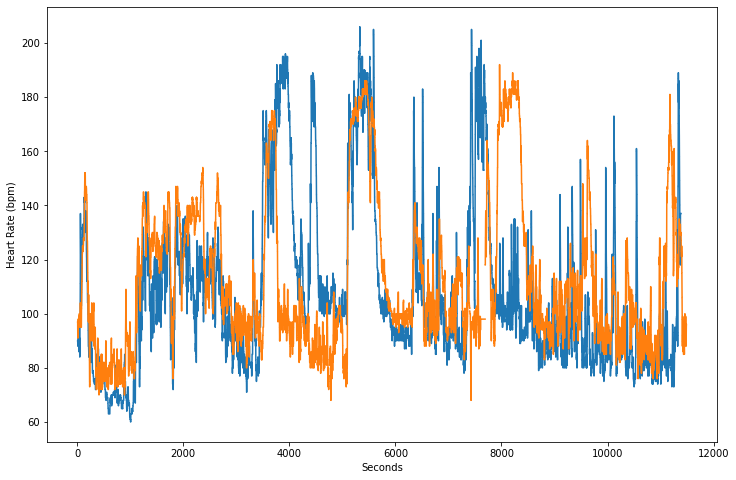

In [30]:
# Ath7_Game_3_8_df = Game_3_8_df.loc[Game_3_8_df['AthleteID'] == 'Athlete 8'] 
(Game_3_8_df.query("AthleteID == 'Athlete 2' or AthleteID == 'Athlete 8'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Heart Rate", ax=plt.gca(), ylabel="Heart Rate (bpm)", figsize=(12,8), legend=False))

AthleteID
Athlete 2    AxesSubplot(0.125,0.125;0.775x0.755)
Athlete 8    AxesSubplot(0.125,0.125;0.775x0.755)
dtype: object

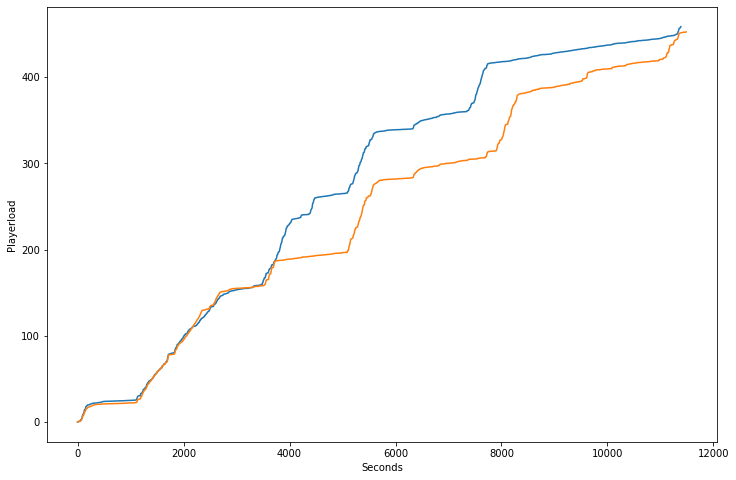

In [29]:
(Game_3_8_df.query("AthleteID == 'Athlete 2' or AthleteID == 'Athlete 8'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Player Load", ax=plt.gca(), ylabel="Playerload", figsize=(12,8), legend=False))